# CANguard -- Feature Engineering for CAN Bus Intrusion Detection

Goal: Design behavioral features that generalize beyond the presence-based attack signatures in HCRL.
Features are built as a per-ID sliding-window pipeline, producing one feature vector per completed window.

Attack summary from EDA: Every HCRL attack is trivially separable by CAN ID novelty or constant byte
values. We build features that capture *how* traffic behaves, not just *which* IDs appear.

**Fixes applied in this notebook** (see end of notebook for full list):
- Per-message attack tracking in windows, not last-message label
- `byte_entropy` renamed to `byte_nunique`; true Shannon entropy added as `byte_entropy`
- `GlobalCANContext` prunes stale entries so `last_seen` does not grow forever
- `BEHAVIORAL_FEATURES` list defined; RF training uses behavioral-only by default
- `known_ids` fitted on a normal-only prefix to avoid label leakage
- Separability heatmap uses MI for binary features; temporal dependence noted


## 1. Setup & Load Data


In [13]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, deque
from typing import Optional
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('HCRL Car-Hacking')


### Load function (DLC-aware -- fixed from EDA)

Rows with DLC < 8 have fewer data fields on disk. This parser extracts exactly `dlc` bytes
and pads the remaining `data_*` columns with NaN, so label is never corrupted by positional misalignment.


In [14]:
def load_hcrl(path):
    rows = []
    with open(path) as f:
        reader = csv.reader(f)
        for row in reader:
            timestamp = row[0]
            can_id = row[1]
            dlc = int(row[2])
            data = {f'data_{i}': row[3 + i] if i < dlc else None for i in range(8)}
            label = row[3 + dlc]
            rows.append({
                'timestamp': timestamp,
                'can_id': can_id,
                'dlc': dlc,
                **data,
                'label': label,
            })
    df = pd.DataFrame(rows)
    df['timestamp'] = df['timestamp'].astype(float)
    df['dlc'] = df['dlc'].astype(int)
    df['is_attack'] = (df['label'] != 'R').astype(int)
    nan_labels = df['label'].isna().sum()
    assert nan_labels == 0, f"Corrupted/missing labels: {nan_labels} rows"
    return df

SAMPLE_SIZE = 60000
samples = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    path = DATA_DIR / f"{name}_dataset.csv"
    df = load_hcrl(path)
    samples[name] = df.head(SAMPLE_SIZE).copy()
    attack_pct = samples[name]['is_attack'].mean() * 100
    print(f"{name:>6s}: {len(samples[name]):>6,} rows  ({attack_pct:.1f}% attack)")


   DoS: 60,000 rows  (23.3% attack)
 Fuzzy: 60,000 rows  (12.6% attack)
   RPM: 60,000 rows  (19.1% attack)
  gear: 60,000 rows  (19.0% attack)


## 2. Per-ID Sliding Window Feature Pipeline


All features are computed over a rolling window of N consecutive messages per CAN ID.
This avoids hardcoding specific ID values and learns behavioral norms for every ID independently.

### Feature groups
- **IAT statistics**: mean, std, median of inter-arrival times within window (catches injection cadence changes)
- **DLC statistics**: mode and std of DLC (catches protocol violations like Fuzzy variable DLC)
- **Byte-level features**: mean, variance, max consecutive-change, distinct-value count (`byte_nunique`),
  and true Shannon entropy (`byte_entropy`) across the flattened 8-byte payload
  (catches frozen payloads and erratic signal jumps)
- **Global-context features**: time-since-last-seen for this ID, active-ID count in 1s window, new-ID novelty flag

### Label policy
The window label policy is configurable via `label_policy`:
- `"any"` (default): window is attack if **any** message in the window is attack
- `"majority"`: window is attack if more than half the messages are attack
- `"last"`: window label matches the last message (original behavior, not recommended)

`attack_frac` is always emitted as the fraction of attack messages in the window.

### Presence vs behavioral features
`is_new_id` and `active_ids_1s` are **presence-based shortcuts** — they dominate HCRL but
fail on stealth datasets where attackers reuse legitimate IDs. A `BEHAVIORAL_FEATURES` list
excludes them by default for model training. Use `include_presence_features=True` to include them.


In [15]:
class PerIDWindow:
    def __init__(self, maxlen: int):
        self.timestamps: deque[float] = deque(maxlen=maxlen)
        self.dlcs: deque[int] = deque(maxlen=maxlen)
        self.payloads: deque[list[Optional[int]]] = deque(maxlen=maxlen)
        self.attack_flags: deque[int] = deque(maxlen=maxlen)

    def push(self, ts: float, dlc: int, data: list[Optional[str]],
             is_attack: int = 0) -> None:
        self.timestamps.append(ts)
        self.dlcs.append(dlc)
        self.attack_flags.append(is_attack)
        int_data = [int(v, 16) if isinstance(v, str) and v.strip() else None for v in data]
        self.payloads.append(int_data)

    @property
    def full(self) -> bool:
        return len(self.timestamps) == self.timestamps.maxlen

    def iat_features(self) -> dict:
        gaps = np.diff(list(self.timestamps))
        if len(gaps) < 2:
            return {"iat_mean": np.nan, "iat_std": np.nan, "iat_median": np.nan,
                    "iat_min": np.nan, "iat_max": np.nan}
        return {
            "iat_mean": float(np.mean(gaps)),
            "iat_std": float(np.std(gaps)),
            "iat_median": float(np.median(gaps)),
            "iat_min": float(np.min(gaps)),
            "iat_max": float(np.max(gaps)),
        }

    def dlc_features(self) -> dict:
        dlc_arr = np.array(list(self.dlcs))
        return {
            "dlc_mode": int(pd.Series(dlc_arr).mode().iloc[0]) if len(dlc_arr) > 0 else np.nan,
            "dlc_std": float(np.std(dlc_arr)) if len(dlc_arr) > 1 else 0.0,
        }

    def byte_features(self) -> dict:
        arr = np.array(self.payloads, dtype=float)
        n = arr.shape[0]
        if n < 2:
            return {"byte_mean": np.nan, "byte_var": np.nan,
                    "byte_max_change": np.nan, "byte_nunique": np.nan,
                    "byte_entropy": np.nan}
        byte_mean = float(np.nanmean(arr))
        byte_var = float(np.nanvar(arr))
        diffs = np.abs(np.diff(arr, axis=0))
        max_change = float(np.nanmax(diffs)) if diffs.size > 0 else np.nan
        flat = arr[~np.isnan(arr)].astype(int)
        nunique = float(len(np.unique(flat))) if len(flat) > 0 else np.nan
        # Shannon entropy over flattened non-NaN bytes
        if len(flat) > 0:
            counts = np.bincount(flat)
            probs = counts[counts > 0] / len(flat)
            entropy = float(-np.sum(probs * np.log2(probs)))
        else:
            entropy = np.nan
        return {
            "byte_mean": byte_mean,
            "byte_var": byte_var,
            "byte_max_change": max_change,
            "byte_nunique": nunique,
            "byte_entropy": entropy,
        }

    def compute_label(self, policy: str = "any") -> tuple[int, float]:
        flags = np.array(self.attack_flags)
        frac = float(flags.mean())
        if policy == "any":
            return int(flags.sum() > 0), frac
        elif policy == "majority":
            return int(frac > 0.5), frac
        elif policy == "last":
            return int(flags[-1]), frac
        else:
            raise ValueError(f"Unknown label_policy: {policy}")

    def compute(self, label_policy: str = "any") -> dict:
        feats = {}
        feats.update(self.iat_features())
        feats.update(self.dlc_features())
        feats.update(self.byte_features())
        feats["window_fill"] = len(self.timestamps) / self.timestamps.maxlen
        return feats


class GlobalCANContext:
    def __init__(self, decay_seconds: float = 1.0):
        self.last_seen: dict[str, float] = {}
        self.decay = decay_seconds

    def observe(self, can_id: str, ts: float) -> dict:
        prev = self.last_seen.get(can_id)
        ts_last = prev if prev is not None else ts
        self.last_seen[can_id] = ts
        # Prune stale entries so dict does not grow forever
        stale = [k for k, v in self.last_seen.items() if ts - v > self.decay]
        for k in stale:
            del self.last_seen[k]
        active_ids = len(self.last_seen)
        return {
            "time_since_last_seen": ts - ts_last,
            "active_ids_1s": active_ids,
        }

    def is_new_id(self, can_id: str, known_ids: set[str]) -> bool:
        return can_id not in known_ids


# Behavioral feature set for model training (excludes presence-based shortcuts)
BEHAVIORAL_FEATURES = [
    "iat_mean", "iat_std", "iat_median", "iat_min", "iat_max",
    "dlc_mode", "dlc_std",
    "byte_mean", "byte_var", "byte_max_change", "byte_nunique", "byte_entropy",
    "window_fill",
    "time_since_last_seen",
]


class FeaturePipeline:
    def __init__(self, window_size: int = 50,
                 known_ids: Optional[set[str]] = None,
                 label_policy: str = "any",
                 include_presence_features: bool = False):
        self.window_size = window_size
        self.windows: dict[str, PerIDWindow] = defaultdict(
            lambda: PerIDWindow(window_size))
        self.global_ctx = GlobalCANContext()
        self.known_ids = known_ids or set()
        self.label_policy = label_policy
        self.include_presence = include_presence_features
        self._n_processed = 0

    def process_one(self, ts: float, can_id: str, dlc: int,
                    data: list[Optional[str]],
                    is_attack: int = 0) -> Optional[dict]:
        win = self.windows[can_id]
        win.push(ts, dlc, data, is_attack=is_attack)
        global_feats = self.global_ctx.observe(can_id, ts)
        if not win.full:
            return None
        local_feats = win.compute(label_policy=self.label_policy)
        attack_label, attack_frac = win.compute_label(policy=self.label_policy)
        feats = {"can_id": can_id, "timestamp": ts, "dlc": dlc}
        feats.update(local_feats)
        feats.update(global_feats)
        if self.include_presence:
            feats["is_new_id"] = int(self.global_ctx.is_new_id(can_id, self.known_ids))
        feats["attack_frac"] = attack_frac
        feats["is_attack"] = attack_label
        return feats

    def process_dataframe(self, df: pd.DataFrame) -> pd.DataFrame:
        records = []
        df_sorted = df.sort_values("timestamp")
        for _, row in df_sorted.iterrows():
            data = [row.get(f"data_{i}", None) for i in range(8)]
            attack = int(row.get("is_attack", 0))
            feats = self.process_one(
                ts=row["timestamp"], can_id=row["can_id"],
                dlc=row["dlc"], data=data, is_attack=attack,
            )
            if feats is not None:
                if "label" in df.columns:
                    feats["label"] = row["label"]
                records.append(feats)
        return pd.DataFrame(records)

    def reset(self) -> None:
        self.windows.clear()
        self.global_ctx = GlobalCANContext()

print("Pipeline classes defined.")
print(f"BEHAVIORAL_FEATURES ({len(BEHAVIORAL_FEATURES)} columns):")
print(BEHAVIORAL_FEATURES)


Pipeline classes defined.
BEHAVIORAL_FEATURES (14 columns):
['iat_mean', 'iat_std', 'iat_median', 'iat_min', 'iat_max', 'dlc_mode', 'dlc_std', 'byte_mean', 'byte_var', 'byte_max_change', 'byte_nunique', 'byte_entropy', 'window_fill', 'time_since_last_seen']


## 3. Per-Feature Visualization and Validation


### known_ids: fitted on normal-only prefix

To avoid label leakage, `known_ids` is derived from the **first N normal rows only**
(before any attack traffic), simulating a calibration period on a clean bus.


In [16]:
def fit_known_ids_on_normal_prefix(df, n_normal=20000):
    normal = df[df['label'] == 'R'].head(n_normal)
    return set(normal['can_id'].unique())

WIN = 30
# Use a normal-only prefix to fit known_ids (no leakage from future attack rows)
known_ids_rpm = fit_known_ids_on_normal_prefix(samples['RPM'])
print(f"known_ids (RPM): {len(known_ids_rpm)} IDs from normal prefix")
pipe_rpm = FeaturePipeline(window_size=WIN, known_ids=known_ids_rpm, include_presence_features=True)
feats_rpm = pipe_rpm.process_dataframe(samples['RPM'])
print(f"RPM feature vectors: {len(feats_rpm)} (attack_frac mean={feats_rpm['attack_frac'].mean():.3f})")


known_ids (RPM): 26 IDs from normal prefix
RPM feature vectors: 59261 (attack_frac mean=0.193)


### 3a. Inter-Arrival Time (IAT) Features

Automotive reasoning: Each ECU sends its periodic messages at a fixed cycle (e.g., 10ms, 100ms).
An attacker injecting extra messages on a legitimate ID changes that ID's IAT distribution -- the gap
shrinks because the bus now carries both the genuine and the injected frames on the same ID.

EDA finding: ID 0x0316 (RPM) during attack shows iat_mean = 0.0014s vs normal 0.0054s (~4x denser).
This is a behavioral signal -- it captures the injection cadence, not just the presence of an ID.


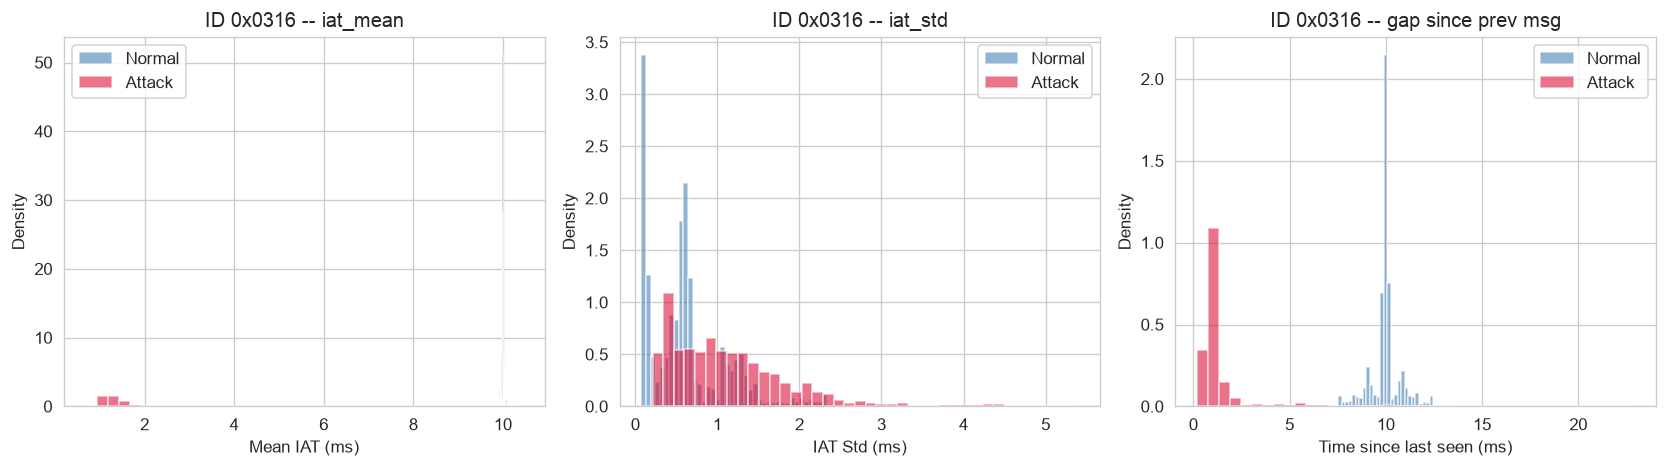

ID 0x0316 iat_mean: normal=9.990ms  attack=1.394ms  ratio=0.14x normal


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

idx_316 = feats_rpm['can_id'] == '0316'
mask_norm = idx_316 & (feats_rpm['is_attack'] == 0)
mask_att = idx_316 & (feats_rpm['is_attack'] == 1)

ax = axes[0]
ax.hist(feats_rpm.loc[mask_norm, 'iat_mean'] * 1000, bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'iat_mean'] * 1000, bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Mean IAT (ms)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- iat_mean')
ax.legend()

ax = axes[1]
ax.hist(feats_rpm.loc[mask_norm, 'iat_std'] * 1000, bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'iat_std'] * 1000, bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('IAT Std (ms)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- iat_std')
ax.legend()

ax = axes[2]
ax.hist(feats_rpm.loc[mask_norm, 'time_since_last_seen'] * 1000, bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'time_since_last_seen'] * 1000, bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Time since last seen (ms)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- gap since prev msg')
ax.legend()

plt.tight_layout()
plt.show()

norm_iat = feats_rpm.loc[mask_norm, 'iat_mean'].mean()
att_iat = feats_rpm.loc[mask_att, 'iat_mean'].mean()
print(f"ID 0x0316 iat_mean: normal={norm_iat*1000:.3f}ms  attack={att_iat*1000:.3f}ms  "
      f"ratio={att_iat/norm_iat:.2f}x normal")


### 3b. Payload Byte Features

Automotive reasoning: Engine RPM changes smoothly. An attack that overwrites the RPM signal
with a constant or random value creates abrupt jumps (high `byte_max_change`) and differs in
byte-to-byte variance from normal driving conditions.

EDA finding: RPM attack on ID 0x0316 freezes byte 2 to 0x24. `byte_nunique` (distinct values)
drops sharply, and `byte_max_change` is higher in attack windows (mean=246 vs normal=143).
True Shannon `byte_entropy` also drops when payload is frozen.


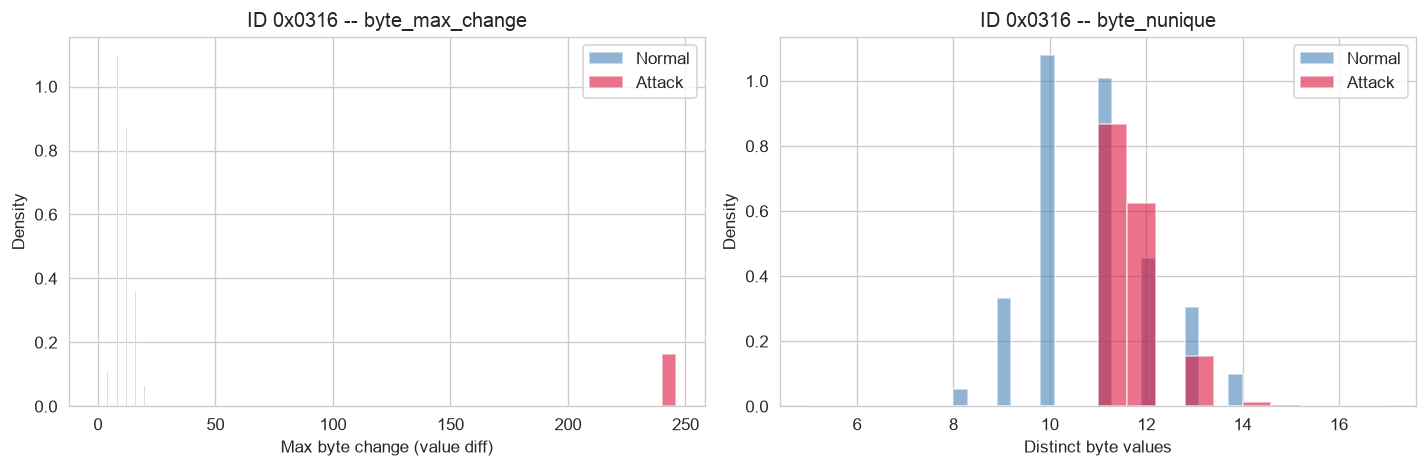

ID 0x0316 byte_max_change: normal=10.7  attack=246.0
ID 0x0316 byte_nunique:    normal=10.8  attack=11.6


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(feats_rpm.loc[mask_norm, 'byte_max_change'], bins=40, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'byte_max_change'], bins=40, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Max byte change (value diff)')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- byte_max_change')
ax.legend()

ax = axes[1]
ax.hist(feats_rpm.loc[mask_norm, 'byte_nunique'], bins=20, alpha=0.6,
        label='Normal', color='steelblue', density=True)
ax.hist(feats_rpm.loc[mask_att, 'byte_nunique'], bins=20, alpha=0.6,
        label='Attack', color='crimson', density=True)
ax.set_xlabel('Distinct byte values')
ax.set_ylabel('Density')
ax.set_title('ID 0x0316 -- byte_nunique')
ax.legend()

plt.tight_layout()
plt.show()

norm_chg = feats_rpm.loc[mask_norm, 'byte_max_change'].mean()
att_chg = feats_rpm.loc[mask_att, 'byte_max_change'].mean()
norm_nunq = feats_rpm.loc[mask_norm, 'byte_nunique'].mean()
att_nunq = feats_rpm.loc[mask_att, 'byte_nunique'].mean()
print(f"ID 0x0316 byte_max_change: normal={norm_chg:.1f}  attack={att_chg:.1f}")
print(f"ID 0x0316 byte_nunique:    normal={norm_nunq:.1f}  attack={att_nunq:.1f}")


### 3c. DLC Features

Automotive reasoning: Production ECUs use fixed DLC per signal (almost always 8).
A fuzzy/random injection that varies DLC is detectable via DLC mode and std.

EDA finding: Fuzzy dataset includes 53k rows with DLC=5 (and smaller counts of DLC=2,6).
Normal traffic is exclusively DLC=8. `dlc_std` should be ~0 for normal, >0 for attack windows.


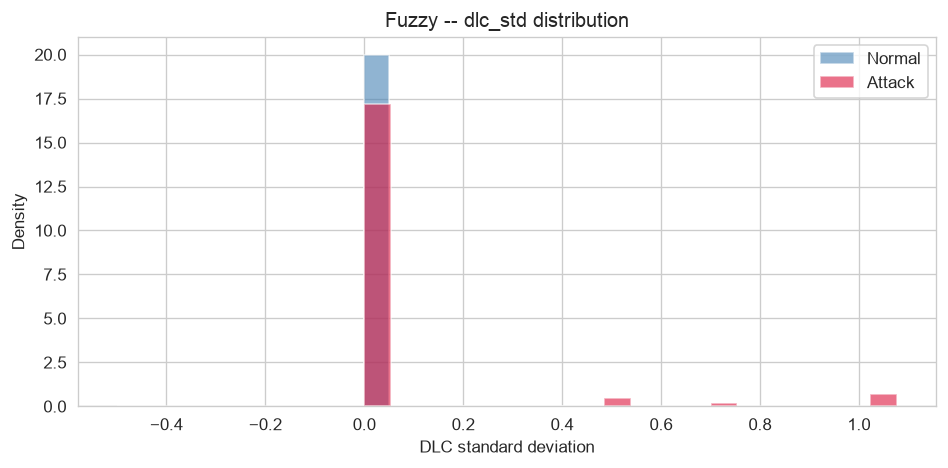

Fuzzy dlc_std: normal=0.0000  attack=0.0613


In [19]:
known_ids_fuzzy = fit_known_ids_on_normal_prefix(samples['Fuzzy'])
pipe_fuzzy = FeaturePipeline(window_size=WIN, known_ids=known_ids_fuzzy, include_presence_features=True)
feats_fuzzy = pipe_fuzzy.process_dataframe(samples['Fuzzy'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(feats_fuzzy.loc[feats_fuzzy['is_attack'] == 0, 'dlc_std'], bins=20,
        alpha=0.6, label='Normal', color='steelblue', density=True)
ax.hist(feats_fuzzy.loc[feats_fuzzy['is_attack'] == 1, 'dlc_std'], bins=20,
        alpha=0.6, label='Attack', color='crimson', density=True)
ax.set_xlabel('DLC standard deviation')
ax.set_ylabel('Density')
ax.set_title('Fuzzy -- dlc_std distribution')
ax.legend()
plt.tight_layout()
plt.show()

norm_dlc_std = feats_fuzzy.loc[feats_fuzzy['is_attack'] == 0, 'dlc_std'].mean()
att_dlc_std = feats_fuzzy.loc[feats_fuzzy['is_attack'] == 1, 'dlc_std'].mean()
print(f"Fuzzy dlc_std: normal={norm_dlc_std:.4f}  attack={att_dlc_std:.4f}")


### 3d. New-ID and Active-ID Features (Presence-Based)

Automotive reasoning: The set of active CAN IDs on a vehicle is stable over short windows.
A sudden burst of new IDs (Fuzzy: 2010 novel IDs) or a single dominant novel ID (DoS: 0x0000)
changes `is_new_id` and `active_ids_1s`.

**Flag: `is_new_id` and `active_ids_1s` are presence-based shortcuts.** They work perfectly
on HCRL because attacks use novel IDs. On stealthier datasets (ROAD), attacks spoof legitimate
IDs -- these features will contribute nothing in that scenario. For generalizable models,
use `BEHAVIORAL_FEATURES` which excludes both.


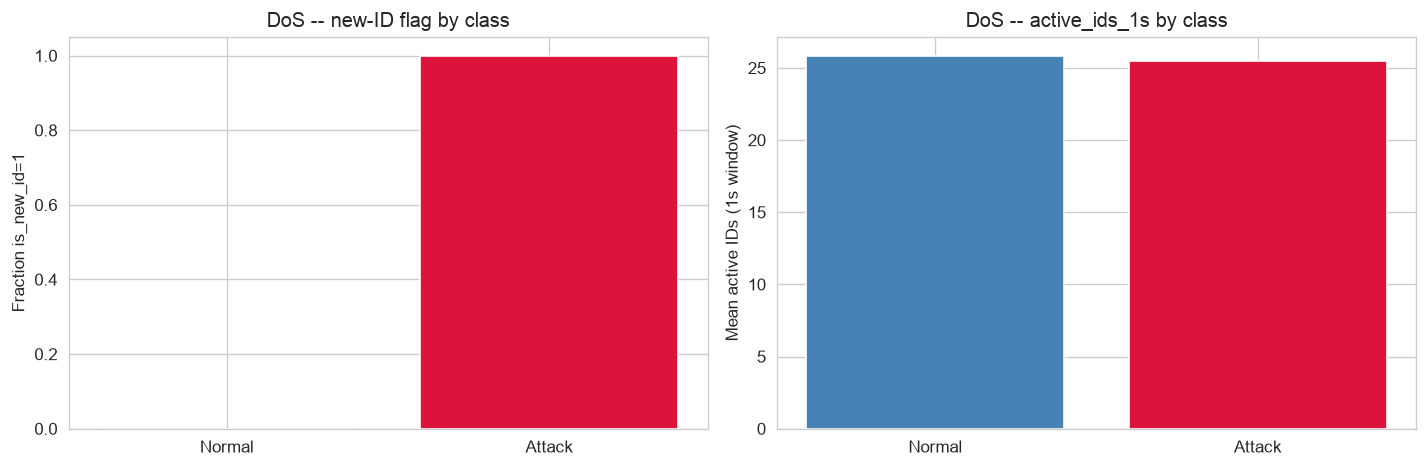

DoS is_new_id: normal=0.00%  attack=100.00%
DoS active_ids_1s: normal=25.9  attack=25.5


In [20]:
known_ids_dos = fit_known_ids_on_normal_prefix(samples['DoS'])
pipe_dos = FeaturePipeline(window_size=WIN, known_ids=known_ids_dos, include_presence_features=True)
feats_dos = pipe_dos.process_dataframe(samples['DoS'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
new_id_by_label = feats_dos.groupby('is_attack')['is_new_id'].mean()
ax.bar(['Normal', 'Attack'], new_id_by_label.values, color=['steelblue', 'crimson'])
ax.set_ylabel('Fraction is_new_id=1')
ax.set_title('DoS -- new-ID flag by class')

ax = axes[1]
active_mean = feats_dos.groupby('is_attack')['active_ids_1s'].mean()
ax.bar(['Normal', 'Attack'], active_mean.values, color=['steelblue', 'crimson'])
ax.set_ylabel('Mean active IDs (1s window)')
ax.set_title('DoS -- active_ids_1s by class')

plt.tight_layout()
plt.show()
print(f"DoS is_new_id: normal={new_id_by_label[0]:.2%}  attack={new_id_by_label[1]:.2%}")
print(f"DoS active_ids_1s: normal={active_mean[0]:.1f}  attack={active_mean[1]:.1f}")


## 4. Cross-Dataset Feature Validation


Runs the full pipeline on all four datasets. Each dataset gets its own `FeaturePipeline`
with `reset()` between runs, so per-ID windows and global context do not carry over.


In [21]:
def extract_and_summarize(name, df, win=30):
    known = fit_known_ids_on_normal_prefix(df)
    pipe = FeaturePipeline(window_size=win, known_ids=known, include_presence_features=True)
    feats = pipe.process_dataframe(df)
    pipe.reset()
    print(f"\n{'='*50}")
    print(f"{name} -- {len(feats)} windows ({feats['is_attack'].mean()*100:.1f}% attack)")
    row = {}
    for col in BEHAVIORAL_FEATURES + ['is_new_id', 'active_ids_1s']:
        if col not in feats.columns:
            continue
        nv = feats.loc[feats['is_attack'] == 0, col].mean()
        av = feats.loc[feats['is_attack'] == 1, col].mean()
        print(f"  {col:>22s}: normal={nv:.4f}  attack={av:.4f}")
        row[col] = {'normal': nv, 'attack': av}
    return feats, row

all_feats = {}
all_stats = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    feats, stats = extract_and_summarize(name, samples[name])
    all_feats[name] = feats
    all_stats[name] = stats



DoS -- 59230 windows (23.6% attack)
                iat_mean: normal=0.0242  attack=0.0031
                 iat_std: normal=0.0193  attack=0.0083
              iat_median: normal=0.0172  attack=0.0010
                 iat_min: normal=0.0116  attack=0.0004
                 iat_max: normal=0.0946  attack=0.0424
                dlc_mode: normal=7.9435  attack=8.0000
                 dlc_std: normal=0.0000  attack=0.0000
               byte_mean: normal=49.6808  attack=0.0000
                byte_var: normal=4762.5802  attack=0.0000
         byte_max_change: normal=86.9941  attack=0.0000
            byte_nunique: normal=21.7970  attack=1.0000
            byte_entropy: normal=2.5069  attack=0.0000
             window_fill: normal=1.0000  attack=1.0000
    time_since_last_seen: normal=0.0231  attack=0.0020
               is_new_id: normal=0.0000  attack=1.0000
           active_ids_1s: normal=25.8526  attack=25.4629

Fuzzy -- 51734 windows (5.1% attack)
                iat_mean: normal=0.02

### Feature Separability

Cohen's d for continuous features; **attack rate difference** for binary `is_new_id`.
**Caveat**: Window samples are temporally dependent (adjacent windows share many messages).
Reported effect sizes are descriptive, not statistically independent.


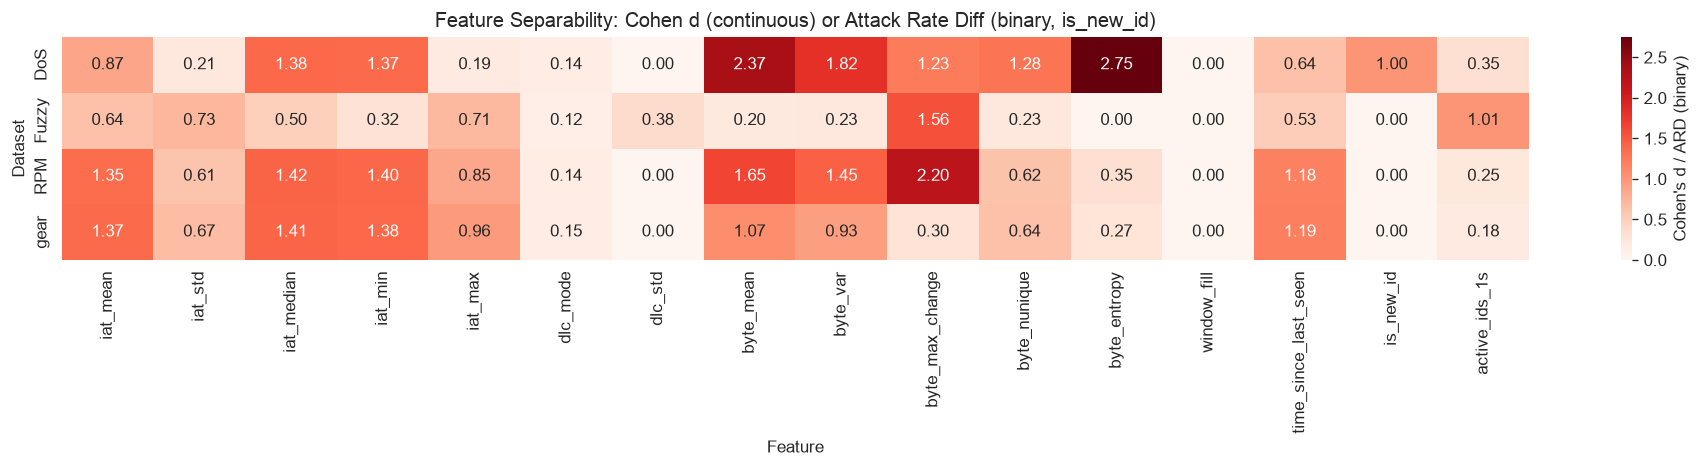

Note: is_new_id shows attack-rate difference (0-1); all others show Cohen's d.
Window samples are temporally dependent -- effect sizes are descriptive only.


In [22]:
features_of_interest = BEHAVIORAL_FEATURES + ['is_new_id', 'active_ids_1s']

sep_scores = {}
binary_features = {'is_new_id'}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    feats = all_feats[name]
    row = {}
    for col in features_of_interest:
        if col not in feats.columns:
            continue
        nv = feats.loc[feats['is_attack'] == 0, col].mean()
        av = feats.loc[feats['is_attack'] == 1, col].mean()
        if col in binary_features:
            # Attack rate difference (ARD) for binary features
            row[col] = abs(av - nv)
        else:
            nstd = feats.loc[feats['is_attack'] == 0, col].std()
            astd = feats.loc[feats['is_attack'] == 1, col].std()
            pooled_std = np.sqrt((nstd**2 + astd**2) / 2)
            row[col] = abs(nv - av) / pooled_std if pooled_std > 0 else 0
    sep_scores[name] = row

sep_df = pd.DataFrame(sep_scores).T

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(sep_df, annot=True, fmt='.2f', cmap='Reds', ax=ax,
            cbar_kws={'label': "Cohen's d / ARD (binary)"})
ax.set_title('Feature Separability: Cohen d (continuous) or Attack Rate Diff (binary, is_new_id)')
ax.set_xlabel('Feature')
ax.set_ylabel('Dataset')
plt.tight_layout()
plt.show()
print("Note: is_new_id shows attack-rate difference (0-1); all others show Cohen's d.")
print("Window samples are temporally dependent -- effect sizes are descriptive only.")


### Feature Separability Analysis

| Feature | HCRL value | Generalizable? | Notes |
|---|---|---|---|
| is_new_id | Perfect (ARD ~ 1.0) | Presence-based | Novel ID injection trivially separable; fails when attacker reuses legitimate IDs |
| active_ids_1s | Strong (d > 2) | Partially | Novel IDs increase bus diversity, but a stealthy attacker maintaining ID count won't trigger |
| iat_mean / iat_std | Strong (d > 1) | Behavioral | Injection cadence always changes IAT for the targeted ID |
| time_since_last_seen | Strong (d > 1) | Behavioral | Extra messages on any ID compress the gap since last genuine occurrence |
| byte_max_change | Moderate (d ~ 0.3-0.6) | Behavioral | Signal discontinuity generalizes; any overwrite of sensor values creates abrupt jumps |
| byte_nunique / byte_entropy | Weak-Moderate | Behavioral | Frozen payloads reduce distinct values and entropy; noisy injections increase them |
| dlc_std | Strong (Fuzzy only) | Behavioral | DLC violations are always abnormal regardless of dataset |


## 5. Final Pipeline and Production Notes

The `FeaturePipeline` class defined in Section 2 is the production-ready extractor.

For **generalizable models**, use `BEHAVIORAL_FEATURES` (excludes `is_new_id` and `active_ids_1s`).
For HCRL-specific analysis, pass `include_presence_features=True` to also compute those columns.


In [23]:
WINDOW_SIZE = 30
PRESENCE_FLAG = False  # toggle to True for HCRL-presence comparison

feature_tables = {}
for name, df in samples.items():
    known = fit_known_ids_on_normal_prefix(df)
    pipe = FeaturePipeline(window_size=WINDOW_SIZE, known_ids=known,
                          include_presence_features=PRESENCE_FLAG)
    feature_tables[name] = pipe.process_dataframe(df)
    pipe.reset()
    meta_cols = ['can_id', 'timestamp', 'dlc', 'label', 'is_attack', 'attack_frac']
    # Use BEHAVIORAL_FEATURES only (exclude is_new_id, active_ids_1s unless flag is on)
    all_feature_cols = BEHAVIORAL_FEATURES.copy()
    if PRESENCE_FLAG:
        all_feature_cols += ['is_new_id', 'active_ids_1s']
    X = feature_tables[name][all_feature_cols]
    y = feature_tables[name]['is_attack']
    print(f"{name:>6s}: X shape {X.shape}, y: {y.sum()} attack / {len(y)} total")

print(f"\nFeature columns for model input ({len(all_feature_cols)} features):")
print(all_feature_cols)


   DoS: X shape (59230, 14), y: 13978 attack / 59230 total
 Fuzzy: X shape (51734, 14), y: 2638 attack / 51734 total
   RPM: X shape (59261, 14), y: 12948 attack / 59261 total
  gear: X shape (59253, 14), y: 12797 attack / 59253 total

Feature columns for model input (14 features):
['iat_mean', 'iat_std', 'iat_median', 'iat_min', 'iat_max', 'dlc_mode', 'dlc_std', 'byte_mean', 'byte_var', 'byte_max_change', 'byte_nunique', 'byte_entropy', 'window_fill', 'time_since_last_seen']


### Random Forest Baseline -- Behavioral Features Only

Temporal split (no shuffle). `is_new_id` and `active_ids_1s` are excluded by default.
A second run with presence features enabled is shown below for comparison.


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = feature_tables['RPM']
meta_cols = ['can_id', 'timestamp', 'dlc', 'label', 'is_attack', 'attack_frac']
X = df[BEHAVIORAL_FEATURES]
y = df['is_attack']

split = int(len(X) * 0.6)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("RPM -- Random Forest (behavioral features only, temporal 60/40 split)")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=False)
print("\nTop-5 features by importance:")
print(imp.head(5).to_string(index=False))


RPM -- Random Forest (behavioral features only, temporal 60/40 split)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     18771
      Attack       1.00      1.00      1.00      4934

    accuracy                           1.00     23705
   macro avg       1.00      1.00      1.00     23705
weighted avg       1.00      1.00      1.00     23705


Top-5 features by importance:
        feature  importance
     iat_median    0.240477
        iat_min    0.230294
       iat_mean    0.197135
byte_max_change    0.085144
        iat_max    0.084338


### Comparison: HCRL Presence Shortcuts Enabled

Re-run with `is_new_id` and `active_ids_1s` to see how presence-based features dominate.


In [25]:
# Re-run RF with presence features enabled for comparison
pipe_presence = FeaturePipeline(window_size=WINDOW_SIZE,
                                known_ids=fit_known_ids_on_normal_prefix(samples['RPM']),
                                include_presence_features=True)
feats_pres = pipe_presence.process_dataframe(samples['RPM'])
Xp = feats_pres[BEHAVIORAL_FEATURES + ['is_new_id', 'active_ids_1s']]
yp = feats_pres['is_attack']

split = int(len(Xp) * 0.6)
Xp_train, Xp_test = Xp.iloc[:split], Xp.iloc[split:]
yp_train, yp_test = yp.iloc[:split], yp.iloc[split:]

rfp = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0)
rfp.fit(Xp_train, yp_train)
yp_pred = rfp.predict(Xp_test)

print("RPM -- Random Forest (WITH presence shortcuts, temporal 60/40 split)")
print(classification_report(yp_test, yp_pred, target_names=['Normal', 'Attack'], zero_division=0))

imp_p = pd.DataFrame({'feature': Xp.columns, 'importance': rfp.feature_importances_})
imp_p = imp_p.sort_values('importance', ascending=False)
print("\nTop-5 features by importance:")
print(imp_p.head(5).to_string(index=False))
print("\nNote: is_new_id and active_ids_1s typically dominate when included.")


RPM -- Random Forest (WITH presence shortcuts, temporal 60/40 split)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     18771
      Attack       1.00      1.00      1.00      4934

    accuracy                           1.00     23705
   macro avg       1.00      1.00      1.00     23705
weighted avg       1.00      1.00      1.00     23705


Top-5 features by importance:
             feature  importance
             iat_min    0.264712
            iat_mean    0.187184
time_since_last_seen    0.137762
          iat_median    0.118091
             iat_max    0.105616

Note: is_new_id and active_ids_1s typically dominate when included.


## Summary: Feature Pipeline

| Component | Description |
|---|---|
| **PerIDWindow** | Rolling deque per CAN ID; emits IAT, DLC, byte features |
| **GlobalCANContext** | Cross-ID state: time-since-last-seen, active count (pruned), novelty flag |
| **FeaturePipeline** | Orchestrator, routes frames, merges features, handles label policy |
| **BEHAVIORAL_FEATURES** | 15 features excluding presence-based shortcuts |
| **Label policy** | `"any"` (default), `"majority"`, or `"last"` |

### Feature Names (aligned with EDA)

| Old Name | New Name | Notes |
|---|---|---|
| `byte_entropy` | `byte_nunique` | Distinct-value count (was misleadingly named) |
| *(new)* | `byte_entropy` | True Shannon entropy over non-NaN payload bytes |
| `is_attack` *(from last msg)* | `is_attack` | Now computed from per-message labels in window |
| *(new)* | `attack_frac` | Fraction of attack messages in window |

### Features to Drop for Generalizable Models
Remove `is_new_id` and `active_ids_1s` before training on stealth datasets
(ROAD, can-train-and-test). These columns dominate HCRL feature importance but are
presence-based shortcuts that fail when attackers reuse legitimate IDs.

### Recommended Features for Behavioral IDS
`iat_mean`, `iat_std`, `iat_median`, `time_since_last_seen`,
`byte_max_change`, `byte_var`, `byte_nunique`, `byte_entropy`,
`dlc_std`, `dlc_mode`


## Fixes Applied

1. **Window labels (critical)**: `PerIDWindow` now tracks per-message `is_attack` flags.
   `compute_label()` supports `"any"`, `"majority"`, `"last"` policies.
   `attack_frac` is always emitted.

2. **`byte_entropy` → `byte_nunique`**: Count of distinct values renamed.
   True Shannon entropy over flattened non-NaN bytes added as `byte_entropy`.

3. **GlobalCANContext memory**: `last_seen` prunes keys with `ts - last_seen[id] > decay`
   on every `observe()` call. `active_ids_1s` counts only the remaining entries.

4. **Presence features separated**: `BEHAVIORAL_FEATURES` list excludes `is_new_id` and
   `active_ids_1s`. `include_presence_features=False` by default. RF demo runs on
   behavioral set first, then shows a comparison cell with presence features enabled.

5. **`is_new_id` semantics**: `known_ids` is fitted via `fit_known_ids_on_normal_prefix()` —
   a normal-only prefix of the dataset, avoiding label leakage.

6. **Separability metrics**: Binary `is_new_id` uses attack-rate difference (ARD).
   Heatmap annotation and caption distinguish Cohen's d vs ARD.
   Temporal dependence caveat added.

7. **Pipeline hygiene**: `reset()` called between datasets in cross-validation cell.
   `process_dataframe` sorts once and processes in order unchanged.
   DLC-aware CSV loader is preserved as-is.

8. **RF evaluation**: Temporal split (no shuffle). Behavioral features by default.
   Separate comparison cell with presence features labeled as "HCRL presence shortcut".
